# Lab 33 — Noise and Detection: Gaussian Statistics, Filtered and Bandpass Noise, Noise Figure and ROC Curves

**Companion to Chapter 3** (*Random Signals and Noise*). Lab 1's dynamic-range section relates ADC resolution and noise figure
to sensitivity; this lab is the chapter's own.
**Time needed:** about 90 minutes. **Difficulty:** core.

Every number in a link budget, every bit-error-rate curve and every detector threshold rests on a few facts about noise: that it
is Gaussian, that filtering shapes its spectrum by $|H(f)|^2$, that bandpass noise splits into two independent baseband halves,
that every lossy or active stage adds its own, and that deciding "signal or no signal" is a trade between detection and false
alarm. This lab generates noise and checks each fact against the formulas of Chapter 3, then uses them: a Friis cascade
calculator, a simulated Y-factor measurement, and ROC curves for the three classic detectors.

### What you will learn
1. Generate real and complex Gaussian noise and check its density, Q-function tails, Rayleigh envelope and uniform phase.
2. Filter white noise and verify $S_y(f) = |H(f)|^2 N_0/2$ and the noise-equivalent bandwidth.
3. Build bandpass noise, downconvert it, and verify the I/Q statistics; detect a hidden BPSK signal by its spectral correlation.
4. Compute cascade noise figure and system temperature (Friis), and simulate a Y-factor measurement.
5. Trace ROC curves for coherent, envelope and energy detectors by Monte Carlo and compare with theory; feel Bayes' base-rate effect.

### Prerequisites
Probability (Gaussian, chi-square), Chapter 2 (spectra, filters). Chapter 3.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Gaussian noise, Q-function tails, Rayleigh and Rice | yes |
| 2 | Filtered noise, PSD and noise-equivalent bandwidth | yes |
| 3 | Bandpass noise and spectral correlation | |
| 4 | Thermal noise, Friis cascades and system temperature | yes |
| 5 | The Y-factor measurement | yes |
| 6 | Detection: ROC curves and base rates | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, signal as sps
from scipy.special import erfc, erfcinv
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=33, lab="33")
K_B = 1.380649e-23
Q = lambda x: 0.5 * erfc(np.asarray(x) / np.sqrt(2))
Qinv = lambda p: np.sqrt(2) * erfcinv(2 * np.asarray(p))

Lab 33 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 33


## 1. Gaussian noise, Q-function tails, Rayleigh and Rice

Thermal noise is the sum of countless independent electron motions, so by the central limit theorem it is Gaussian. The probability
that a zero-mean, unit-variance Gaussian exceeds $x$ is the **Q-function**, $Q(x) = \tfrac12\mathrm{erfc}(x/\sqrt2)$; every binary
error rate is a Q-function of a distance-to-noise ratio. Chapter 3's worked example: a BER of $10^{-12}$ needs $Q^{-1}(10^{-12}) = 7.03$,
a 16.9 dB SNR at the decision point; $10^{-6}$ needs 13.5 dB; a KP4 FEC that accepts $2\times10^{-4}$ needs only 11 dB.
Complex circular Gaussian noise $n_I + jn_Q$ has a **Rayleigh** envelope and a **uniform** phase; add a constant (a line-of-sight
component, Rician factor $K$) and the envelope becomes **Rician**.

### Interactive: sample size and Rician K

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

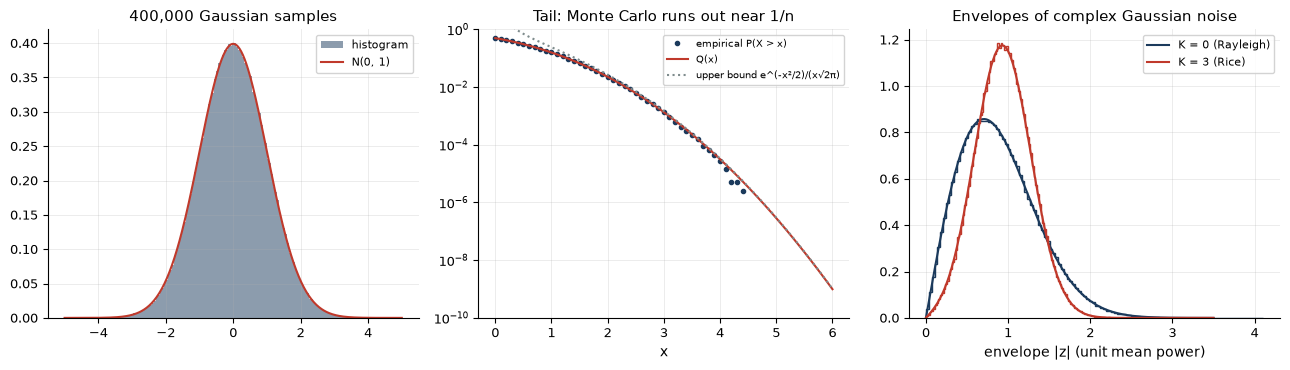

,
"mean, variance of x","+0.0014, 1.0009"
kurtosis E[x⁴],3.001 (Gaussian: 3)
"phase of z: mean, std","-0.001, 1.817 rad (uniform: 0, π/√3 = 1.814)"
E|z|² and P(|z|² > 3·mean),"1.001, 0.0500 (theory e⁻³ = 0.0498)"
"Q⁻¹(1e-12), Q⁻¹(1e-6), Q⁻¹(2e-4)","7.03, 4.75, 3.54"
SNR needed (20 log Q⁻¹),"16.9, 13.5, 11.0 dB"


In [3]:
def gauss_demo(n=400_000, K=3.0):
    r = np.random.default_rng(3)
    x = r.standard_normal(n)
    fig, ax = lk.fig((13, 3.8), 1, 3)
    xs = np.linspace(-5, 5, 400)
    ax[0].hist(x, bins=150, density=True, color=lk.NAVY, alpha=0.5, label="histogram")
    ax[0].plot(xs, stats.norm.pdf(xs), color=lk.RED, label="N(0, 1)"); ax[0].legend(fontsize=8); ax[0].set_title(f"{n:,} Gaussian samples")
    th = np.linspace(0, 6, 61)
    emp = np.array([np.mean(x > t) for t in th])
    ax[1].semilogy(th, np.where(emp > 0, emp, np.nan), "o", ms=3, color=lk.NAVY, label="empirical P(X > x)")
    ax[1].semilogy(th, Q(th), color=lk.RED, label="Q(x)")
    ax[1].semilogy(th, np.exp(-th ** 2 / 2) / (th * np.sqrt(2 * np.pi) + 1e-9), ":", color=lk.GRAY, label="upper bound e^(-x²/2)/(x√2π)")
    ax[1].set_ylim(1e-10, 1); ax[1].set_xlabel("x"); ax[1].legend(fontsize=7.5); ax[1].set_title("Tail: Monte Carlo runs out near 1/n")
    e = np.linspace(0, 3.5, 300)
    for KK, col in [(0, lk.NAVY), (K, lk.RED)]:
        s = np.sqrt(KK / (KK + 1)); sig = np.sqrt(1 / (2 * (KK + 1)))
        z = s + sig * (r.standard_normal(n) + 1j * r.standard_normal(n))
        ax[2].hist(np.abs(z), bins=120, density=True, histtype="step", color=col)
        ax[2].plot(e, stats.rice.pdf(e, s / sig, scale=sig), color=col, label=f"K = {KK:g}" + (" (Rayleigh)" if KK == 0 else " (Rice)"))
    ax[2].set_xlabel("envelope |z| (unit mean power)"); ax[2].legend(fontsize=8); ax[2].set_title("Envelopes of complex Gaussian noise")
    lk.show(fig)
    z = (r.standard_normal(n) + 1j * r.standard_normal(n)) / np.sqrt(2)
    lk.table([["mean, variance of x", f"{x.mean():+.4f}, {x.var():.4f}"], ["kurtosis E[x⁴]", f"{np.mean(x ** 4):.3f} (Gaussian: 3)"],
              ["phase of z: mean, std", f"{np.angle(z).mean():+.3f}, {np.angle(z).std():.3f} rad (uniform: 0, π/√3 = {np.pi / np.sqrt(3):.3f})"],
              ["E|z|² and P(|z|² > 3·mean)", f"{np.mean(np.abs(z) ** 2):.3f}, {np.mean(np.abs(z) ** 2 > 3):.4f} (theory e⁻³ = {np.exp(-3):.4f})"],
              ["Q⁻¹(1e-12), Q⁻¹(1e-6), Q⁻¹(2e-4)", f"{Qinv(1e-12):.2f}, {Qinv(1e-6):.2f}, {Qinv(2e-4):.2f}"],
              ["SNR needed (20 log Q⁻¹)", f"{20 * np.log10(Qinv(1e-12)):.1f}, {20 * np.log10(Qinv(1e-6)):.1f}, {20 * np.log10(Qinv(2e-4)):.1f} dB"]], ["", ""])

lk.interact(gauss_demo, n=lk.choice([10_000, 100_000, 400_000, 2_000_000], 400_000, "samples"), K=lk.slider(3, 0, 20, 0.5, "Rician K"))

**What you should see.** The histogram on the bell curve; the empirical tail on $Q(x)$ until it runs out of samples at about
$1/n$: no simulation of $10^{-12}$ is possible this way, which is why BER curves at low error rates are extrapolated from theory. The
Rayleigh envelope, and a Rician one that narrows around $\sqrt{K/(K+1)}$ as $K$ grows. The table reproduces the chapter's 16.9, 13.5
and 11 dB.

### Try it yourself 1.1
What SNR (dB, $20\log_{10}Q^{-1}$) does a BER of $10^{-9}$ require?

In [5]:
answer_1_1 = None
lk.check("1.1 SNR for BER 1e-9 (dB)", answer_1_1, 20 * np.log10(Qinv(1e-9)), atol=0.05)

[TODO] 1.1 SNR for BER 1e-9 (dB): not attempted yet: replace the None with your answer

## 2. Filtered noise, PSD and noise-equivalent bandwidth

White noise of two-sided PSD $N_0/2$ through a filter $H(f)$ has PSD $|H(f)|^2N_0/2$ and power $N_0B_N|H(0)|^2$, where the
**noise-equivalent bandwidth** $B_N = \int_0^\infty|H(f)|^2df/|H(0)|^2$ is the width of the rectangle with the same area. For an
$n$-pole Butterworth, $B_N/f_{3\,\mathrm{dB}} = (\pi/2n)/\sin(\pi/2n)$: 1.571 for one pole, 1.111 for two. Chapter 3's worked example:
an RC low-pass has $B_N = 1/(4RC)$, so the noise on a capacitor is $kT/C$, independent of $R$: 64 µV for 1 pF at 300 K.

### Interactive: filter order and cut-off

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

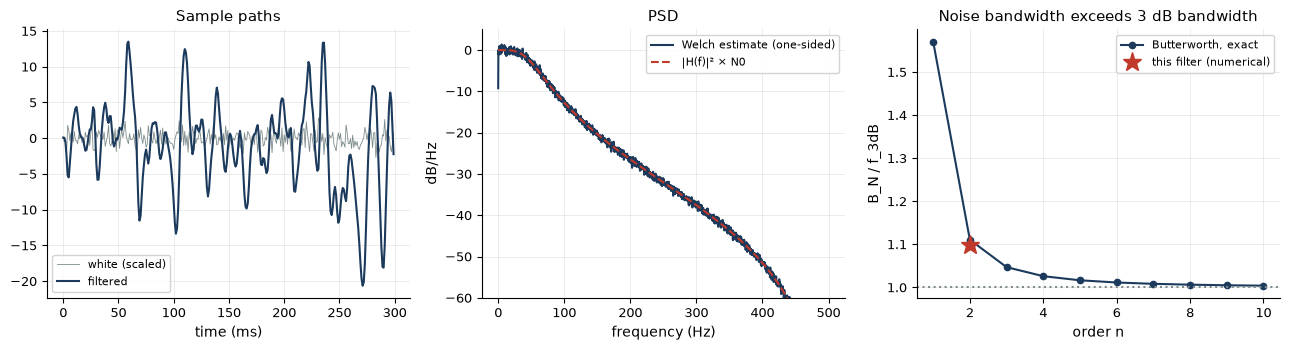

,
measured output power,55.06
N0·B_N (numerical B_N),54.87
B_N / f_3dB,1.097 (formula 1.111)
"kT/C noise, 1 pF at 300 K",64 µV rms


In [7]:
def filt_demo(order=2, fc=50.0, fs=1000.0):
    r = np.random.default_rng(2)
    N = 1 << 17
    w = r.standard_normal(N) * np.sqrt(fs / 2)                    # two-sided PSD N0/2 = 1/2 (one-sided 1 per Hz)
    b, a = sps.butter(order, fc, fs=fs)
    y = sps.lfilter(b, a, w)
    f, p = sps.welch(y, fs, nperseg=4096)
    fw, H = sps.freqz(b, a, worN=8192, fs=fs)
    BN = np.trapezoid(np.abs(H) ** 2, fw)
    fig, ax = lk.fig((13, 3.6), 1, 3)
    t = np.arange(300) / fs * 1e3
    ax[0].plot(t, w[:300] / np.sqrt(fs / 2), color=lk.GRAY, lw=0.6, label="white (scaled)"); ax[0].plot(t, y[:300], color=lk.NAVY, label="filtered")
    ax[0].set_xlabel("time (ms)"); ax[0].legend(fontsize=8); ax[0].set_title("Sample paths")
    ax[1].plot(f, lk.db(p), color=lk.NAVY, label="Welch estimate (one-sided)"); ax[1].plot(fw, lk.db(np.abs(H) ** 2), "--", color=lk.RED, label="|H(f)|² × N0")
    ax[1].set_ylim(-60, 5); ax[1].set_xlabel("frequency (Hz)"); ax[1].set_ylabel("dB/Hz"); ax[1].legend(fontsize=8); ax[1].set_title("PSD")
    nn = np.arange(1, 11)
    ax[2].plot(nn, (np.pi / (2 * nn)) / np.sin(np.pi / (2 * nn)), "o-", color=lk.NAVY, label="Butterworth, exact")
    ax[2].plot(order, BN / fc, "*", ms=14, color=lk.RED, label="this filter (numerical)")
    ax[2].axhline(1, color=lk.GRAY, ls=":"); ax[2].set_xlabel("order n"); ax[2].set_ylabel("B_N / f_3dB"); ax[2].legend(fontsize=8)
    ax[2].set_title("Noise bandwidth exceeds 3 dB bandwidth")
    lk.show(fig)
    lk.table([["measured output power", f"{np.var(y):.2f}"], ["N0·B_N (numerical B_N)", f"{BN:.2f}"],
              ["B_N / f_3dB", f"{BN / fc:.3f} (formula {(np.pi / (2 * order)) / np.sin(np.pi / (2 * order)):.3f})"],
              ["kT/C noise, 1 pF at 300 K", f"{np.sqrt(K_B * 300 / 1e-12) * 1e6:.0f} µV rms"]], ["", ""])

lk.interact(filt_demo, order=lk.islider(2, 1, 8, 1, "Butterworth order"), fc=lk.slider(50, 10, 200, 5, "cut-off (Hz)"), fs=lk.choice([1000.0, 2000.0], 1000.0, "sample rate (Hz)"))

**What you should see.** The filtered noise wanders slowly (its autocorrelation has widened as its spectrum narrowed); its Welch
PSD lies on $|H(f)|^2N_0$; and the measured power equals $N_0B_N$ with $B_N$ 11% above the 3 dB bandwidth for a 2-pole filter,
57% for one pole. The $kT/C$ row: 64 µV, as in the chapter.

### Try it yourself 2.1
What sampling capacitance (pF) keeps $kT/C$ noise at 300 K equal to 35 µV (the quantisation noise of a 2 V, 14-bit ADC)?

In [9]:
answer_2_1 = None
lk.check("2.1 capacitance for 35 uV kT/C noise (pF)", answer_2_1, K_B * 300 / (35e-6) ** 2 * 1e12, atol=0.1)

[TODO] 2.1 capacitance for 35 uV kT/C noise (pF): not attempted yet: replace the None with your answer

## 3. Bandpass noise and spectral correlation

Noise filtered to a band of width $B$ around $f_c$ can be written $n(t) = n_I(t)\cos 2\pi f_ct - n_Q(t)\sin 2\pi f_ct$, with $n_I$ and
$n_Q$ independent low-pass Gaussian processes of the *same* power as $n(t)$ (each with twice its PSD, squeezed into half the band). The
complex envelope $\tilde n = n_I + jn_Q$ is circular. Noise is also **stationary**, while modulated signals are **cyclostationary**:
their spectral components at frequencies $\alpha$ apart are correlated. A BPSK signal at −10 dB SNR is invisible in the PSD, but its
spectral coherence shows lines at the symbol rate and, for the conjugate correlation, at twice the carrier: noise shows nothing.

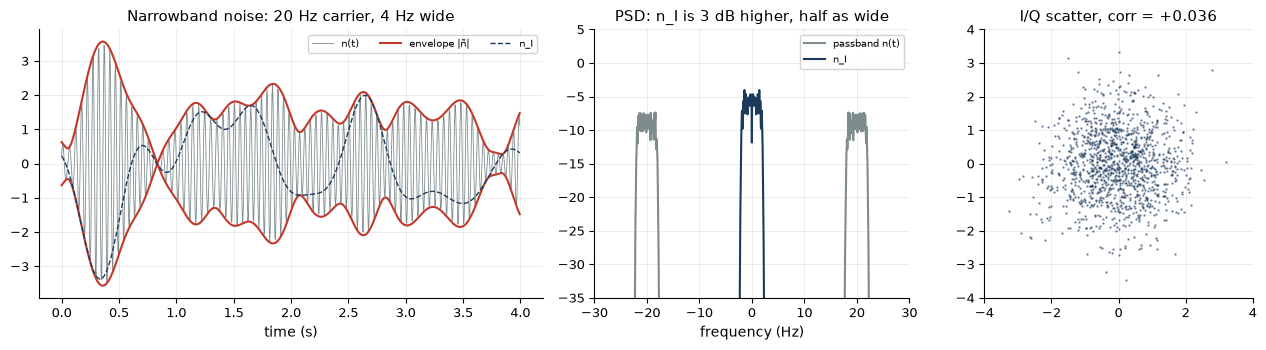

bandpass noise,
power of n(t),1.000
"power of n_I, n_Q","0.980, 1.017"
power of complex envelope E|ñ|²,2.000 (= 2 × power of n)


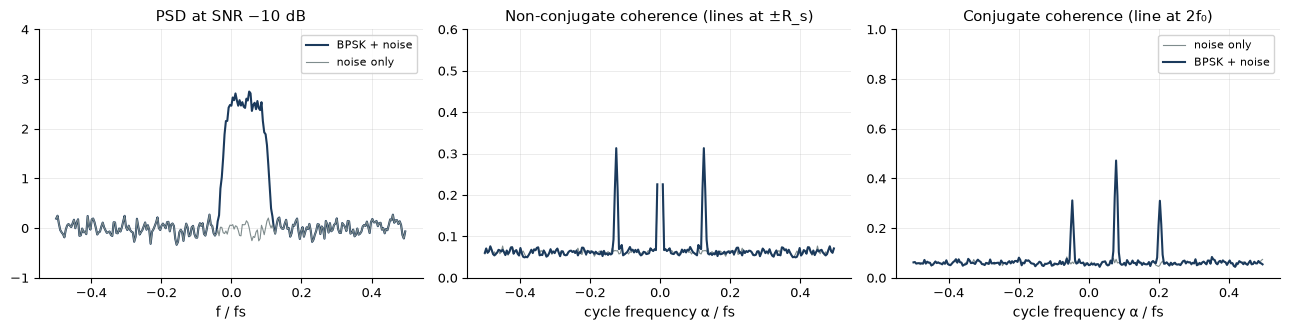

In [11]:
r = np.random.default_rng(7)
fs, N, fc, B = 200.0, 1 << 15, 20.0, 4.0
w = r.standard_normal(N)
nbp = np.convolve(w, sps.firwin(801, [fc - B / 2, fc + B / 2], pass_zero=False, fs=fs), mode="same")
nbp /= np.std(nbp)
t = np.arange(N) / fs
env = sps.hilbert(nbp) * np.exp(-2j * np.pi * fc * t)
fig, ax = lk.fig((13, 3.6), 1, 3, gridspec_kw=dict(width_ratios=[1.6, 1, 1]))
sl = slice(4000, 4000 + int(4 * fs))
ax[0].plot(t[sl] - t[sl][0], nbp[sl], color=lk.GRAY, lw=0.6, label="n(t)")
ax[0].plot(t[sl] - t[sl][0], np.abs(env[sl]), color=lk.RED, label="envelope |ñ|"); ax[0].plot(t[sl] - t[sl][0], -np.abs(env[sl]), color=lk.RED)
ax[0].plot(t[sl] - t[sl][0], env[sl].real, "--", color=lk.NAVY, lw=1, label="n_I"); ax[0].legend(fontsize=7.5, ncol=3); ax[0].set_xlabel("time (s)")
ax[0].set_title(f"Narrowband noise: {fc:g} Hz carrier, {B:g} Hz wide")
f_, p_ = sps.welch(nbp, fs, nperseg=4096, return_onesided=False); fi, pI = sps.welch(env.real, fs, nperseg=4096, return_onesided=False)
o = np.argsort(f_)
ax[1].plot(f_[o], lk.db(p_[o] + 1e-12), color=lk.GRAY, label="passband n(t)"); ax[1].plot(fi[o], lk.db(pI[o] + 1e-12), color=lk.NAVY, label="n_I")
ax[1].set_xlim(-30, 30); ax[1].set_ylim(-35, 5); ax[1].legend(fontsize=7.5); ax[1].set_xlabel("frequency (Hz)"); ax[1].set_title("PSD: n_I is 3 dB higher, half as wide")
ax[2].plot(env.real[::25], env.imag[::25], ".", ms=1.5, color=lk.NAVY, alpha=0.5); ax[2].set_aspect("equal"); ax[2].set_xlim(-4, 4); ax[2].set_ylim(-4, 4)
ax[2].set_title(f"I/Q scatter, corr = {np.corrcoef(env.real, env.imag)[0, 1]:+.3f}")
lk.show(fig)
lk.table([["power of n(t)", f"{np.var(nbp):.3f}"], ["power of n_I, n_Q", f"{np.var(env.real):.3f}, {np.var(env.imag):.3f}"],
          ["power of complex envelope E|ñ|²", f"{np.mean(np.abs(env) ** 2):.3f} (= 2 × power of n)"]], ["bandpass noise", ""])

# spectral coherence of BPSK at -10 dB vs noise alone
Nf, sp_, nblk, k0 = 256, 8, 1500, 10
sym = r.choice([-1.0, 1.0], Nf * nblk // sp_)
xb = cl.shape(sym, cl.rrc_taps(0.35, sp_, 8), sp_)[:Nf * nblk]
xb = xb / np.sqrt(np.mean(np.abs(xb) ** 2)) * np.exp(2j * np.pi * k0 * np.arange(Nf * nblk) / Nf)
noise = (r.standard_normal(len(xb)) + 1j * r.standard_normal(len(xb))) / np.sqrt(2) * np.sqrt(10)

def coherence(sig):
    X = np.fft.fft(sig.reshape(nblk, Nf) * np.hanning(Nf), axis=1)
    P = np.mean(np.abs(X) ** 2, 0); k = np.arange(Nf); nc, cj = [], []
    for d in range(-Nf // 2, Nf // 2):
        S = np.mean(X[:, (k + d) % Nf] * np.conj(X), 0)
        nc.append(np.nan if abs(d) <= 1 else np.max(np.abs(S) / np.sqrt(P[(k + d) % Nf] * P)))
        S2 = np.mean(X * X[:, (d - k) % Nf], 0)
        cj.append(np.max(np.abs(S2) / np.sqrt(P * P[(d - k) % Nf])))
    return np.arange(-Nf // 2, Nf // 2) / Nf, np.array(nc), np.array(cj), P

a_s, nc_s, cj_s, P_s = coherence(xb + noise)
a_n, nc_n, cj_n, P_n = coherence(noise)
fig, ax = lk.fig((13, 3.4), 1, 3)
fr = np.fft.fftshift(np.fft.fftfreq(Nf))
ax[0].plot(fr, lk.db(np.fft.fftshift(P_s) / np.median(P_n)), color=lk.NAVY, label="BPSK + noise"); ax[0].plot(fr, lk.db(np.fft.fftshift(P_n) / np.median(P_n)), color=lk.GRAY, lw=0.8, label="noise only")
ax[0].set_ylim(-1, 4); ax[0].legend(fontsize=8); ax[0].set_xlabel("f / fs"); ax[0].set_title("PSD at SNR −10 dB")
ax[1].plot(a_n, nc_n, color=lk.GRAY, lw=0.8); ax[1].plot(a_s, nc_s, color=lk.NAVY); ax[1].set_ylim(0, 0.6); ax[1].set_xlabel("cycle frequency α / fs"); ax[1].set_title("Non-conjugate coherence (lines at ±R_s)")
ax[2].plot(a_n, cj_n, color=lk.GRAY, lw=0.8, label="noise only"); ax[2].plot(a_s, cj_s, color=lk.NAVY, label="BPSK + noise"); ax[2].set_ylim(0, 1); ax[2].legend(fontsize=8)
ax[2].set_xlabel("cycle frequency α / fs"); ax[2].set_title("Conjugate coherence (line at 2f₀)")
lk.show(fig)

**What you should see.** The bandpass noise looks like a carrier with a slowly wandering envelope and phase. Its in-phase component
has the *same* power as $n(t)$ but twice the PSD over half the width, and the complex envelope carries twice the power, the "factor
of two" bookkeeping of Chapter 3. The I/Q scatter is a circular cloud with zero correlation. In the second figure, the PSD barely
rises above the noise (−10 dB SNR), yet the spectral coherence of BPSK + noise shows clear lines at $\alpha = \pm R_s = \pm f_s/8$
and, for the conjugate coherence, at $2f_0 = 20/256$, where noise alone stays flat. This is how spectrum sensors detect signals below
the noise floor without knowing their content.

## 4. Thermal noise, Friis cascades and system temperature

A resistor at temperature $T$ delivers $kTB$ to a matched load: −174 dBm/Hz at 290 K. A stage of noise factor $F$ and gain $G$ adds
$(F-1)kT_0$ referred to its input, and in a cascade the later stages' contributions are divided by the gain ahead of them (Friis):
$F = F_1 + (F_2-1)/G_1 + (F_3-1)/(G_1G_2) + \ldots$. A passive loss $L$ at physical temperature $T_0$ has $F = L$. Chapter 3's handset
example: switch 0.5 dB, SAW 1.5 dB, LNA (1 dB, 18 dB), mixer (10 dB, 8 dB), baseband (12 dB, 30 dB), ADC (27 dB): 3.58 dB in all.

### Interactive: the line-up (reorder by moving the LNA)

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

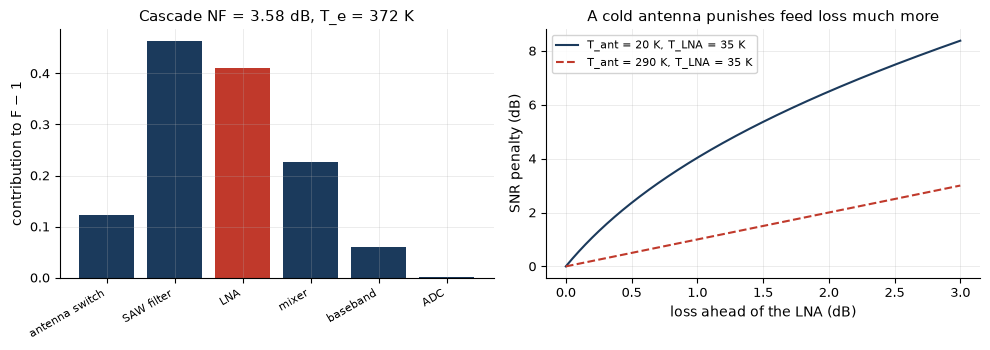

stage,gain (dB),NF (dB),adds to F,cumulative NF (dB),cumulative gain (dB)
antenna switch,-0.5,0.5,0.122,0.5,-0.5
SAW filter,-1.5,1.5,0.463,2,-2
LNA,18,1,0.41,3,16
mixer,8,10,0.226,3.47,24
baseband,30,12,0.0591,3.58,54
ADC,0,27,0.00199,3.58,54


,
system temperature T_ant + T_e,662 K
noise floor in 10 MHz,-100.4 dBm
"kT0B in 1 MHz (50 Ω, 290 K)","-114.0 dBm, 0.89 µV rms open circuit"


In [13]:
def cascade(stages):
    F, G, rows = 1.0, 1.0, []
    for name, g_db, nf_db in stages:
        add = (lk.undb(nf_db) - 1) / G
        F += add; G *= lk.undb(g_db)
        rows.append([name, g_db, nf_db, add, lk.db(F), lk.db(G)])
    return lk.db(F), rows

def friis_demo(lna_first=False, lna_nf=1.0, lna_gain=18.0, feed_loss=2.0, t_ant=290.0):
    stages = [("antenna switch", -0.5, 0.5), ("SAW filter", -1.5, 1.5), ("LNA", lna_gain, lna_nf), ("mixer", 8.0, 10.0),
              ("baseband", 30.0, 12.0), ("ADC", 0.0, 27.0)]
    if feed_loss > 0:
        stages = [("feed line", -feed_loss, feed_loss)] + stages
    if lna_first:
        lna = [s for s in stages if s[0] == "LNA"][0]
        stages = [lna] + [s for s in stages if s[0] != "LNA"]
    nf, rows = cascade(stages)
    Te = 290 * (lk.undb(nf) - 1)
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].bar(range(len(rows)), [r_[3] for r_ in rows], color=[lk.RED if r_[0] == "LNA" else lk.NAVY for r_ in rows])
    ax[0].set_xticks(range(len(rows))); ax[0].set_xticklabels([r_[0] for r_ in rows], rotation=30, ha="right", fontsize=8)
    ax[0].set_ylabel("contribution to F − 1"); ax[0].set_title(f"Cascade NF = {nf:.2f} dB, T_e = {Te:.0f} K")
    Ldb = np.linspace(0, 3, 300); L = lk.undb(Ldb)
    for Ta, Tl, col, ls in [(20, 35, lk.NAVY, "-"), (290, 35, lk.RED, "--")]:
        Tsys = Ta / L + 290 * (1 - 1 / L) + Tl
        ax[1].plot(Ldb, lk.db(Tsys / (Ta + Tl)) + Ldb, color=col, ls=ls, label=f"T_ant = {Ta} K, T_LNA = {Tl} K")
    ax[1].set_xlabel("loss ahead of the LNA (dB)"); ax[1].set_ylabel("SNR penalty (dB)"); ax[1].legend(fontsize=8)
    ax[1].set_title("A cold antenna punishes feed loss much more")
    lk.show(fig)
    lk.table(rows, ["stage", "gain (dB)", "NF (dB)", "adds to F", "cumulative NF (dB)", "cumulative gain (dB)"], fmt=".3g")
    Tsys = t_ant + Te
    lk.table([["system temperature T_ant + T_e", f"{Tsys:.0f} K"], ["noise floor in 10 MHz", f"{lk.db(K_B * Tsys * 10e6 * 1e3):.1f} dBm"],
              ["kT0B in 1 MHz (50 Ω, 290 K)", f"{lk.db(K_B * 290 * 1e6 * 1e3):.1f} dBm, {np.sqrt(4 * K_B * 290 * 50 * 1e6) * 1e6:.2f} µV rms open circuit"]], ["", ""])

lk.interact(friis_demo, lna_first=lk.choice([False, True], False, "LNA at the antenna"), lna_nf=lk.slider(1.0, 0.3, 4.0, 0.1, "LNA NF (dB)"),
            lna_gain=lk.slider(18, 6, 30, 1, "LNA gain (dB)"), feed_loss=lk.slider(0, 0, 4, 0.1, "feed-line loss (dB)"), t_ant=lk.slider(290, 10, 300, 5, "antenna temperature (K)"))

**What you should see.** With no feed loss the table reproduces the chapter: cumulative NF 0.50, 2.00, 3.00, 3.47, 3.58 dB; the 2 dB of
passive loss ahead of the LNA costs more than the LNA itself, and the ADC adds 0.002. Add 2 dB of feed line: the NF rises by 2 dB. Move
the LNA to the antenna (a mast-head amplifier or a satellite LNB) and the losses behind it almost vanish from the budget. The right
panel shows why satellite ground stations care so much: with a 20 K sky and a 35 K LNA, 1 dB of loss ahead of the LNA costs about 4 dB of SNR
(1 dB of signal and about 3 dB of extra noise temperature), against exactly 1 dB for a warm antenna.

### Try it yourself 4.1
What is the open-circuit noise voltage density (nV/√Hz) of a 1 kΩ resistor at 290 K?

In [15]:
answer_4_1 = None
lk.check("4.1 noise density of 1 kOhm (nV/rtHz)", answer_4_1, np.sqrt(4 * K_B * 290 * 1e3) * 1e9, atol=0.05)

[TODO] 4.1 noise density of 1 kOhm (nV/rtHz): not attempted yet: replace the None with your answer

## 5. The Y-factor measurement

Connect a noise source with excess noise ratio ENR to the device: the output noise power with the source on and off differs by
$Y = (T_h + T_e)/(T_c + T_e)$, so $F = \mathrm{ENR}/(Y-1)$ (with $T_c = T_0$). The analyzer's own noise is a second stage and is removed with
Friis. Chapter 3's worked example: ENR 15 dB, a 20 dB LNA, an 8 dB analyzer, a measured Y of 13.5 dB give 1.70 dB for the system and
1.54 dB for the LNA. Below, the measurement is *simulated*: noise power is estimated from a finite number of samples, so $Y$ is uncertain,
and that uncertainty maps into the NF.

### Interactive: ENR, DUT noise figure and averaging

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

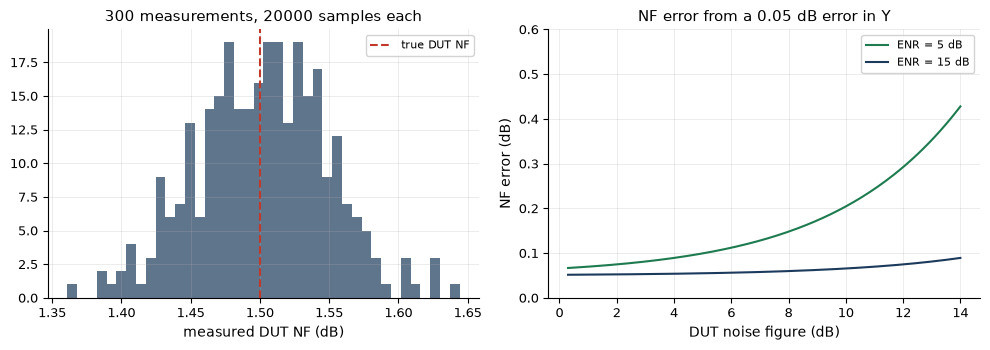

,
mean measured DUT NF,1.502 dB
standard deviation,0.048 dB
Chapter 3: system NF from Y = 13.5 dB,1.70 dB
Chapter 3: LNA NF after 2nd-stage correction,1.54 dB (123 K)
hot/cold: Y = 5.05 dB with 290 K / 77 K loads,T_e = 20 K


In [17]:
def yfactor_demo(enr_db=15.0, dut_nf=1.5, dut_gain=20.0, ana_nf=8.0, n_avg=20000):
    r = np.random.default_rng(4)
    T0 = 290.0
    Te_dut = T0 * (lk.undb(dut_nf) - 1); Te_ana = T0 * (lk.undb(ana_nf) - 1); G = lk.undb(dut_gain)
    Th = T0 * (lk.undb(enr_db) + 1)
    trials = 300
    def meas(Ts):
        Tout = G * (Ts + Te_dut) + Te_ana                       # output noise temperature (per unit kB)
        return Tout * np.mean(r.exponential(1.0, (trials, n_avg)), axis=1)    # power estimates from n_avg samples
    Y = meas(Th) / meas(T0)
    Fsys = lk.undb(enr_db) / (Y - 1)
    F1 = Fsys - (lk.undb(ana_nf) - 1) / G
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].hist(lk.db(F1), bins=40, color=lk.NAVY, alpha=0.7); ax[0].axvline(dut_nf, color=lk.RED, ls="--", label="true DUT NF")
    ax[0].set_xlabel("measured DUT NF (dB)"); ax[0].legend(fontsize=8); ax[0].set_title(f"{trials} measurements, {n_avg} samples each")
    nf = np.linspace(0.3, 14, 200); F = lk.undb(nf)
    for e_db, col in [(5, lk.GREEN), (15, lk.NAVY)]:
        e = lk.undb(e_db); Yt = e / F + 1; Fp = e / (Yt * lk.undb(0.05) - 1)
        ax[1].plot(nf, np.abs(lk.db(Fp / F)), color=col, label=f"ENR = {e_db} dB")
    ax[1].set_ylim(0, 0.6); ax[1].set_xlabel("DUT noise figure (dB)"); ax[1].set_ylabel("NF error (dB)"); ax[1].legend(fontsize=8)
    ax[1].set_title("NF error from a 0.05 dB error in Y")
    lk.show(fig)
    Yw = lk.undb(13.5); Fw = lk.undb(15) / (Yw - 1); F1w = Fw - (lk.undb(8) - 1) / 100
    lk.table([["mean measured DUT NF", f"{np.mean(lk.db(F1)):.3f} dB"], ["standard deviation", f"{np.std(lk.db(F1)):.3f} dB"],
              ["Chapter 3: system NF from Y = 13.5 dB", f"{lk.db(Fw):.2f} dB"], ["Chapter 3: LNA NF after 2nd-stage correction", f"{lk.db(F1w):.2f} dB ({290 * (F1w - 1):.0f} K)"],
              ["hot/cold: Y = 5.05 dB with 290 K / 77 K loads", f"T_e = {(290 - lk.undb(5.05) * 77) / (lk.undb(5.05) - 1):.0f} K"]], ["", ""])

lk.interact(yfactor_demo, enr_db=lk.choice([5.0, 15.0], 15.0, "ENR (dB)"), dut_nf=lk.slider(1.5, 0.3, 10, 0.1, "true DUT NF (dB)"),
            dut_gain=lk.slider(20, 0, 40, 1, "DUT gain (dB)"), ana_nf=lk.slider(8, 3, 25, 1, "analyzer NF (dB)"),
            n_avg=lk.choice([1000, 20000, 200000], 20000, "samples per power estimate"))

**What you should see.** The simulated measurements cluster around the true NF with a spread set by the averaging; the table
reproduces the chapter's 1.70 dB (system), 1.54 dB (LNA, 123 K) and about 20 K for the cryogenic hot–cold case. Reduce the DUT gain to
0 dB: the second-stage correction becomes large and the result very sensitive. The right panel is Chapter 3's warning: a low-ENR source
is more accurate for low-NF devices, a high-ENR source for noisy ones.

## 6. Detection: ROC curves and base rates

Deciding between $H_0$ (noise) and $H_1$ (signal + noise) means comparing a statistic with a threshold, trading the probability of
detection $P_D$ against the probability of false alarm $P_{FA}$ (Neyman–Pearson). Three classic detectors: **coherent** (known signal
and phase): $P_D = Q(Q^{-1}(P_{FA}) - \sqrt{2E/N_0})$; **envelope** (unknown phase): $P_D = Q_1(\sqrt{2E/N_0}, \sqrt{-2\ln P_{FA}})$
(Marcum Q); **energy** (nothing known, $N$ complex samples): central and noncentral chi-square with $2N$ degrees of freedom. Below, all
three by Monte Carlo against the formulas. And Chapter 3's Bayes example: a detector with $P_D = 0.99$, $P_{FA} = 10^{-3}$, and
a prior of $10^{-4}$ is right only 9% of the times it fires.

### Interactive: SNR and energy-detector length

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

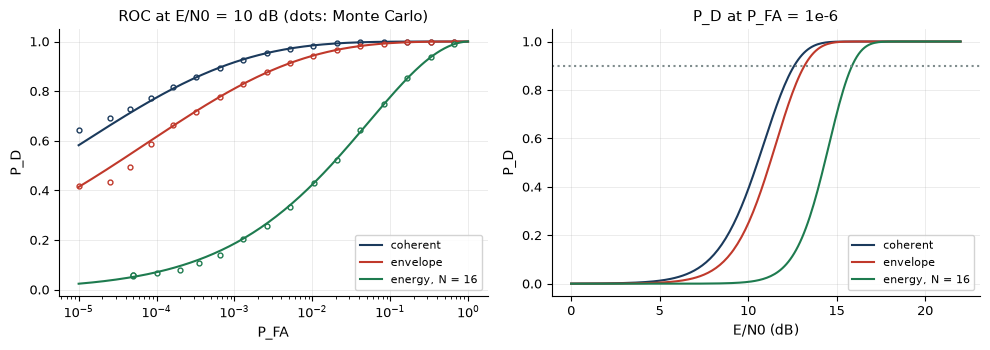

,
E/N0 for P_D = 0.9 at P_FA = 1e-6: coherent,12.7 dB
… envelope,13.3 dB
"… energy, N = 16",15.9 dB
"P(signal | alarm), P_D = 0.99, P_FA = 1e-3, prior 0.0001",0.090


In [19]:
def roc_demo(snr_db=10.0, N=16, prior=1e-4, trials=200_000):
    from scipy.stats import ncx2, chi2
    r = np.random.default_rng(6)
    E = lk.undb(snr_db)                                     # E/N0 of the whole observation
    pfa = np.logspace(-5, 0, 200)
    n0 = (r.standard_normal(trials) + 1j * r.standard_normal(trials)) / np.sqrt(2)
    n1 = (r.standard_normal(trials) + 1j * r.standard_normal(trials)) / np.sqrt(2)
    s = np.sqrt(E)
    coh0, coh1 = n0.real * np.sqrt(2), (s + n1).real * np.sqrt(2)        # matched filter, known phase
    ph = np.exp(2j * np.pi * r.random(trials))
    env0, env1 = np.abs(n0) ** 2, np.abs(s * ph + n1) ** 2               # unknown phase
    w0 = (r.standard_normal((trials // 10, N)) + 1j * r.standard_normal((trials // 10, N))) / np.sqrt(2)
    w1 = (r.standard_normal((trials // 10, N)) + 1j * r.standard_normal((trials // 10, N))) / np.sqrt(2) + np.sqrt(E / N) * np.exp(2j * np.pi * r.random((trials // 10, N)))
    en0, en1 = np.sum(np.abs(w0) ** 2, axis=1), np.sum(np.abs(w1) ** 2, axis=1)
    emp = lambda h0, h1: (np.array([np.mean(h0 > np.quantile(h0, 1 - p)) for p in pfa]), np.array([np.mean(h1 > np.quantile(h0, 1 - p)) for p in pfa]))
    fig, ax = lk.fig("row2", 1, 2)
    for (h0, h1), th, col, lab in [((coh0, coh1), Q(Qinv(pfa) - np.sqrt(2 * E)), lk.NAVY, "coherent"),
                                    ((env0, env1), ncx2.sf(chi2.isf(pfa, 2), 2, 2 * E), lk.RED, "envelope"),
                                    ((en0, en1), ncx2.sf(chi2.isf(pfa, 2 * N), 2 * N, 2 * E), lk.GREEN, f"energy, N = {N}")]:
        pf_, pd_ = emp(h0, h1)
        ax[0].semilogx(pf_[::12], pd_[::12], "o", ms=3.5, color=col, mfc="white")
        ax[0].semilogx(pfa, th, color=col, label=lab)
    ax[0].set_xlabel("P_FA"); ax[0].set_ylabel("P_D"); ax[0].legend(fontsize=8); ax[0].set_title(f"ROC at E/N0 = {snr_db:g} dB (dots: Monte Carlo)")
    sd = np.linspace(0, 22, 200); e_ = lk.undb(sd); P6 = 1e-6
    ax[1].plot(sd, Q(Qinv(P6) - np.sqrt(2 * e_)), color=lk.NAVY, label="coherent")
    ax[1].plot(sd, ncx2.sf(chi2.isf(P6, 2), 2, 2 * e_), color=lk.RED, label="envelope")
    ax[1].plot(sd, ncx2.sf(chi2.isf(P6, 2 * N), 2 * N, 2 * e_), color=lk.GREEN, label=f"energy, N = {N}")
    ax[1].axhline(0.9, color=lk.GRAY, ls=":"); ax[1].set_xlabel("E/N0 (dB)"); ax[1].set_ylabel("P_D"); ax[1].legend(fontsize=8); ax[1].set_title("P_D at P_FA = 1e-6")
    lk.show(fig)
    need = lambda fpd: sd[np.argmax(fpd >= 0.9)]
    post = 0.99 * prior / (0.99 * prior + 1e-3 * (1 - prior))
    lk.table([["E/N0 for P_D = 0.9 at P_FA = 1e-6: coherent", f"{need(Q(Qinv(P6) - np.sqrt(2 * e_))):.1f} dB"],
              ["… envelope", f"{need(ncx2.sf(chi2.isf(P6, 2), 2, 2 * e_)):.1f} dB"], [f"… energy, N = {N}", f"{need(ncx2.sf(chi2.isf(P6, 2 * N), 2 * N, 2 * e_)):.1f} dB"],
              [f"P(signal | alarm), P_D = 0.99, P_FA = 1e-3, prior {prior:g}", f"{post:.3f}"]], ["", ""])

lk.interact(roc_demo, snr_db=lk.slider(10, 0, 20, 0.5, "E/N0 (dB)"), N=lk.choice([1, 4, 16, 64], 16, "energy-detector samples N"),
            prior=lk.choice([1e-4, 1e-2, 0.5], 1e-4, "prior probability of a signal"), trials=lk.choice([50_000, 200_000], 200_000, "trials"))

**What you should see.** Simulated points on the theoretical ROCs; the coherent detector best, the envelope detector only about half a decibel worse at these error rates
(the cost of not knowing the phase), and the energy detector worse still, by an amount that grows with $N$ (it integrates noise from
$N$ samples to collect the same signal energy). At $P_{FA} = 10^{-6}$ and $P_D = 0.9$ the gap between coherent and energy detection is
several dB. The base-rate row reproduces the chapter: 0.090, so 91% of alarms are false; raise the prior to 0.5 and nearly every alarm
is real.

### Try it yourself 6.1
A link measures $C/N_0 = 60$ dB-Hz and needs $E_b/N_0 = 2$ dB. What is the maximum bit rate (kb/s), before any margin?

In [21]:
answer_6_1 = None
lk.check("6.1 max bit rate at 60 dB-Hz (kb/s)", answer_6_1, 10 ** ((60 - 2) / 10) / 1e3, atol=5)

[TODO] 6.1 max bit rate at 60 dB-Hz (kb/s): not attempted yet: replace the None with your answer

## Key takeaways
* Noise is Gaussian; error rates are Q-functions; Monte Carlo cannot reach $10^{-12}$, theory can.
* Filtering shapes the PSD by $|H(f)|^2$; noise power is $N_0B_N$, and $B_N > f_{3\,\mathrm{dB}}$. $kT/C$ is independent of R.
* Bandpass noise = two independent baseband halves; signals are cyclostationary, noise is not.
* Friis: the first stages dominate; loss ahead of the LNA counts in full, and hurts most with a cold antenna.
* Y-factor measurements depend on averaging, ENR choice and second-stage correction.
* Detection trades $P_D$ for $P_{FA}$; knowing more about the signal buys dB; base rates make rare-event detectors mostly wrong.

## Going further (hardware: USRP B200 / GNU Radio)
* Terminate the B200's RX2 input with a 50 Ω load and capture with `gnuradio/gr01_spectrum_iq_capture.py`: check the noise is Gaussian
  and circular, and estimate the receiver's noise figure from the power at known gain (then compare with the datasheet).
* With an inexpensive noise source (a broadband noise diode module), perform a real Y-factor measurement of the B200's front end.

## Exercises
1. **(Warm-up)** Derive $B_N = 1/(4RC)$ for an RC low-pass filter.
2. **(Core)** Add a second interferer to Section 3 at a different symbol rate and show both cycle frequencies.
3. **(Core)** Compute the system temperature of Chapter 3's satellite downlink (60 cm dish, 120 K) and reproduce $C/N_0 = 89.4$ dB-Hz.
4. **(Stretch)** Implement a cyclostationary detector for BPSK at a known symbol rate and compare its ROC with the energy detector at −10 dB SNR.

In [23]:
lk.summary()

[good] Lab 33 finished in 10.4 s. Self-checks: 0 passed, 0 failed, 4 still to do.